* **nombre**: Marcos Bianchi
* **padrón**: 108921

## 1. Implemente un perceptrón simple que aprenda la función lógica AND y la función lógica OR, de 2 y de 4 entradas. Muestre la evolución del error durante el entrenamiento. Para el caso de 2 dimensiones, grafique la recta discriminadora y todos los vectores de entrada de la red.

In [1]:
import matplotlib.pyplot as plt
import numpy as np


def plot_errors(errors: list[float], gate: str):
    xs = list(range(1, len(errors) + 1))

    plt.plot(xs, errors)
    plt.title(f"Perceptron training error in each iteration for an {gate} gate")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.xticks(xs)
    plt.grid(True)
    plt.show()

def plot_weights(ws: list[tuple[float, float, float]], gate: str):
    points = [(-1, -1), (-1, 1), (1, -1), (1, 1)]

    # Create a grid of points
    x_min, x_max = -1.5, 1.5
    y_min, y_max = -1.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    # Create subplots (one column per weight set)
    fig, axes = plt.subplots(1, len(ws), figsize=(6 * len(ws), 6), squeeze=False)

    for ax, (w1, w2, b) in zip(axes[0], ws):
        # Compute perceptron output over the grid
        Z = w1 * xx + w2 * yy + b
        Z = np.sign(Z)  # classify: -1 or +1

        # Fill each region
        ax.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.3, colors=["#ffcccc", "#ccccff"])

        # Draw the decision boundary
        ax.contour(xx, yy, Z, levels=[0], colors="blue")

        # Plot training points
        xs, ys = zip(*points)
        ax.scatter(xs, ys, color="red", edgecolor="black", zorder=5, label="Points")

        ax.set_title(f"weights: ({w1.item():.2f}, {w2.item():.2f}, {b:.2f})")

        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.grid(True)

    fig.suptitle(f"{gate} gate")
    plt.tight_layout()
    plt.show()

$$AND$$
|x1|x2|y|
|-|-|-|
|1|1|1|
|1|-1|-1|
|-1|1|-1|
|-1|-1|-1|

In [2]:
from src.perceptron import Perceptron
import numpy as np

p = Perceptron(2)
X = np.array([
    [1, 1],
    [1, -1],
    [-1, 1],
    [-1, -1],
])
Y = np.array([
    [1],
    [-1],
    [-1],
    [-1],
])

ws = []
errors = []
def telemeter(p: Perceptron):
    error = p.mse(X, Y)
    errors.append(error)

    ws.append((p.W[0], p.W[1], p.B))


p.train(X, Y, f=telemeter)

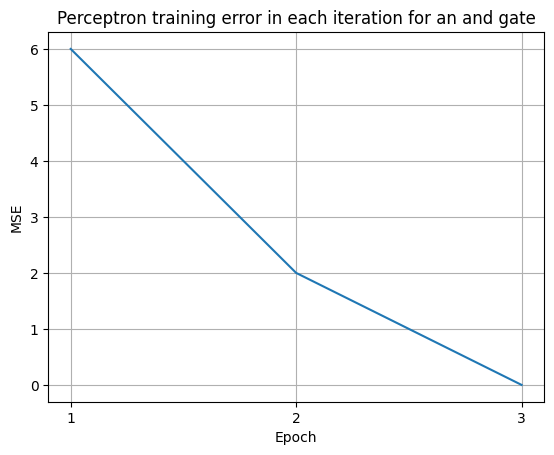

In [3]:
plot_errors(errors, "and")

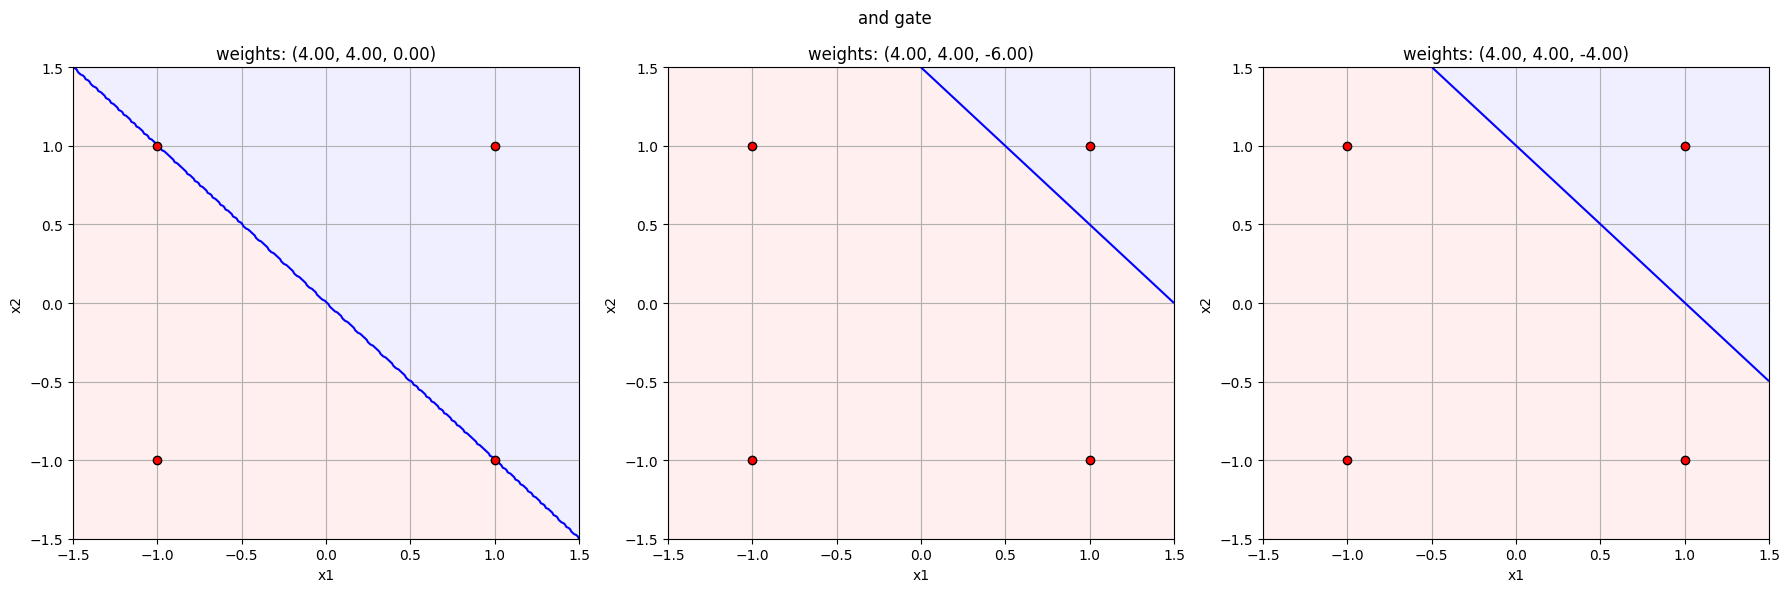

In [4]:
plot_weights(ws, "and")